<a href="https://colab.research.google.com/github/ronaldmourao/BiotrAIn-hub-spokes/blob/main/BiotrAIn_Module_1_2_Data_Pre_Processing_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1.2 Data Preprocessing for Machine Learning Pipeline
**Authors:**  
J. Noé García-Chávez  
Alejandra Rougon-Cardoso  

###Introduction

In this notebook, we will build a complete pipeline to use RNA-seq data obtained from [Sequence Read Archive (SRA)](https://www.ncbi.nlm.nih.gov/sra) database to train a machine learning model to classify the samples into two classes.

We will focus on a critical idea:

Raw biological data cannot be used directly for machine learning, it must be carefully preprocessed.  

---
###Learning objectives

By the end of this notebook, you should be able to:  
* Perform pre-processing  of RNA-seq data for machine learning model
* Filter low-quality samples and genes
* Understand and correct batch effects
* Normalize high-dimensional biological data
* Train and evaluate a classification model
* Interpret PCAs and confusion matrices


---

###Pipeline overview

We will follow these steps:
1. Load and align data
2. Raw Data Exploration
3. Explore Samples Sparsity
4. Filter Low-Quality Samples
5. Low Expressed Genes Filtering
6. Batch Effects Correction
7. Split Data and Feature Scaling
8. Model training
9. Use a SVM Model to Predict Test Dataset Classes
10. Train a Similar Model Using the Original data
11. Models Comparison


#Classification of _Arabidopsis thaliana_ Transcriptomic Data to Predict Above- and Below-Ground Tissues

Public repositories host thousands of transcriptomic datasets from a wide variety of plant experiments. These data enable large-scale meta-analyses; however, inconsistent or incomplete metadata annotation can limit the reliability of biological interpretations and classification tasks.

To address this limitation, we developed a machine learning framework to infer sample metadata directly from gene expression profiles. In this notebook, we present an approach to classify Arabidopsis thaliana samples into above- and below-ground tissues using transcriptomic data obtained from public repositories. This model is designed to enable the annotation and classification of samples with incomplete or absent tissue metadata in _Arabidopsis thaliana_, thereby improving the usability of large-scale public datasets.

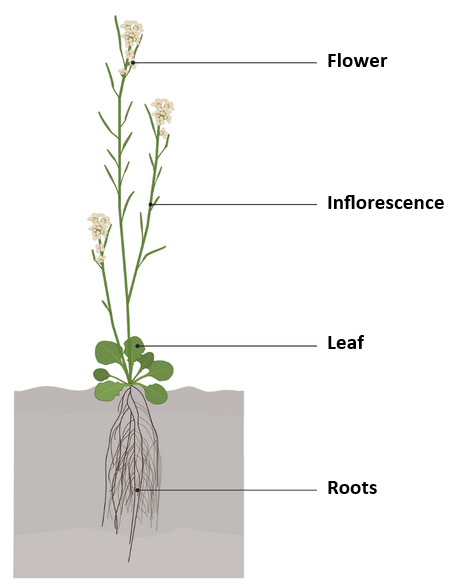

*Figure 1. Basic structure of Arabidopsis thaliana showing main tissues from above-ground and below-ground tissues*

RNA-seq data was obtained from the SRA database. The data have been processed locally to obtain gene expression levels (raw counts) for all mRNAs in _Arabidopsis thaliana_.

Using these gene expression profiles as features, we train a Support Vector Machine (SVM) model to classify biological samples into above-ground and below-ground tissues. However, because the data come from multiple independent studies—with variations in sequencing depth, experimental conditions, and technical factors, raw data cannot be used directly.

Therefore, this notebook focuses on the importance of preprocessing steps, including filtering, normalization, and batch correction, to ensure reliable model training. Finally, we compare the performance of a model trained on properly preprocessed data with a model trained on the original, unprocessed data.

### 0. Environment setup

Install required modules.

In [ ]:
!pip install scanpy anndata pycombat seaborn scikit-learn
# Install gdown
!pip install -q gdown

**Load packages**

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import gdown
import os

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.model_selection import train_test_split

###1. Obtain Expression File and Metadata
We load:

Gene expression matrix (genes in rows × samples in columns)  
Metadata (sample annotations in columns)

Download the data from a drive

In [ ]:
# Create directory
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

# Expression and metadata files IDs
file1_id = "1ODNJmQ5BSiXy02F82mMzB3S1tyT1ck6u"
file2_id = "1w_Lvn-_Lq7am5857FH1XifzMa3b0mRUR"

# Output paths (you can rename extensions if needed)
file1_path = os.path.join(DATA_DIR, "file1")
file2_path = os.path.join(DATA_DIR, "file2")

# Download
gdown.download(f"https://drive.google.com/uc?id={file1_id}", file1_path, quiet=False)
gdown.download(f"https://drive.google.com/uc?id={file2_id}", file2_path, quiet=False)

print(os.listdir(DATA_DIR))

Downloading...
From: https://drive.google.com/uc?id=1ODNJmQ5BSiXy02F82mMzB3S1tyT1ck6u
To: /content/data/file1
100%|██████████| 1.76M/1.76M [00:00<00:00, 55.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1w_Lvn-_Lq7am5857FH1XifzMa3b0mRUR
To: /content/data/file2
100%|██████████| 6.74k/6.74k [00:00<00:00, 2.35MB/s]

['file2', 'file1']


Load expression and metadata, then check the alignment of the samples and its metadata

In [ ]:
import pandas as pd

counts = pd.read_csv(file1_path, index_col=0)
metadata = pd.read_csv(file2_path, index_col=0)

# Check alignment
print((counts.columns == metadata.index).all())  # Should be True

True


We check that the samples order correspond in counts and in the metadata.

In [ ]:
print(counts.columns[:10])
print(metadata.index[:10])

Index(['SRX2248347', 'DRX292470', 'ERX8932534', 'SRX7478608', 'SRX2932830',
       'SRX9582289', 'DRX291844', 'SRX2932807', 'DRX292444', 'SRX10204658'],
      dtype='object')
Index(['SRX2248347', 'DRX292470', 'ERX8932534', 'SRX7478608', 'SRX2932830',
       'SRX9582289', 'DRX291844', 'SRX2932807', 'DRX292444', 'SRX10204658'],
      dtype='object', name='SampleID')


**First, we check the first lines of the expression data**  
Sample IDs from the SRA database are shown in the columns: SRX2248347, DRX292470, ERX8932534, etc.
Genes are shown in rows: AT4G33850, AT1G12650, etc.

In [ ]:
counts[0:5]

,SRX2248347,DRX292470,ERX8932534,SRX7478608,SRX2932830,SRX9582289,DRX291844,SRX2932807,DRX292444,SRX10204658,...,SRX2248436,SRX2511094,SRX2733552,ERX9154561,DRX292463,SRX10633916,SRX10442552,DRX292448,ERX1268164,SRX8610037
SampleID,,,,,,,,,,,,,,,,,,,,,
AT4G33850,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AT1G12650,892,369,3392,1359,9,967,186,28,304,7,...,470,561,365,3285,431,937,1670,552,455,2551
AT4G06760,665,501,3228,2030,29,1845,204,60,544,29,...,513,1063,751,1252,514,588,1914,746,594,401
AT4G06526,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
AT5G08490,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Then, we check metadata:**  
study_accession: columns shows the SRA database ID of the study.  
classes: column shows the two classes we have: **Above** and **Below** tissues.

In [ ]:
metadata[0:5]

,study_accession,classes
SampleID,,
SRX2248347,SRP091641,Above
DRX292470,DRP010209,Above
ERX8932534,ERP136536,Below
SRX7478608,SRP239091,Above
SRX2932830,SRP109649,Above


###2. Raw data exploration

Before any data processing, we visualize the raw data.

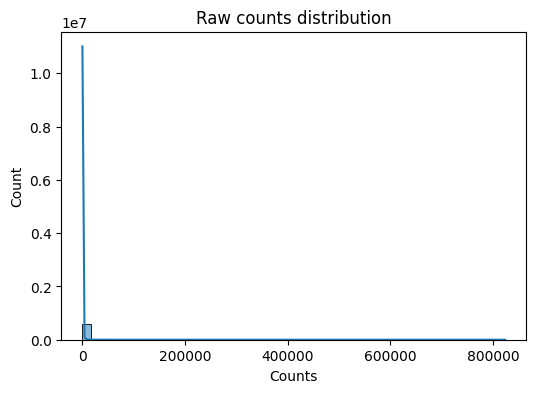

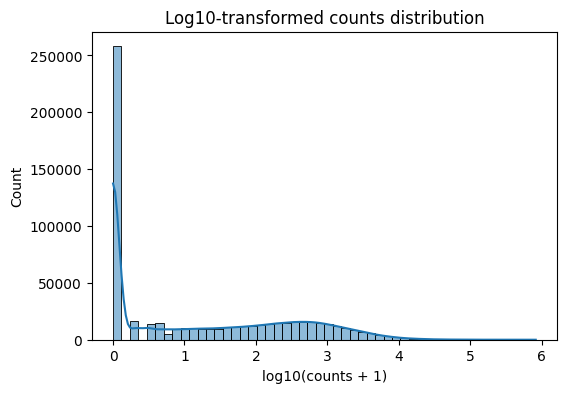

In [ ]:
import numpy as np

plt.figure(figsize=(6,4))
sns.histplot(counts.values.flatten(), bins=50, kde=True)
plt.title("Raw counts distribution")
plt.xlabel("Counts")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(np.log10(counts.values.flatten() + 1), bins=50, kde=True)
plt.title("Log10-transformed counts distribution")
plt.xlabel("log10(counts + 1)")
plt.show()


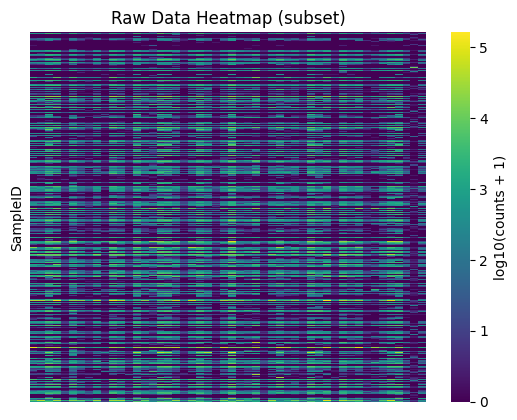

In [ ]:

sns.heatmap(
    np.log10(counts.iloc[:500, :50] + 1),
    cmap='viridis',
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"label": "log10(counts + 1)"}
)

plt.title("Raw Data Heatmap (subset)")
plt.show()


- The distribution is typically highly skewed, with many low or zero values

- The heatmap reveals sparsity (many dark/low-expression regions)

---
This confirms the need for filtering and normalization

###Principal Components Anaysis (PCA) colored by class

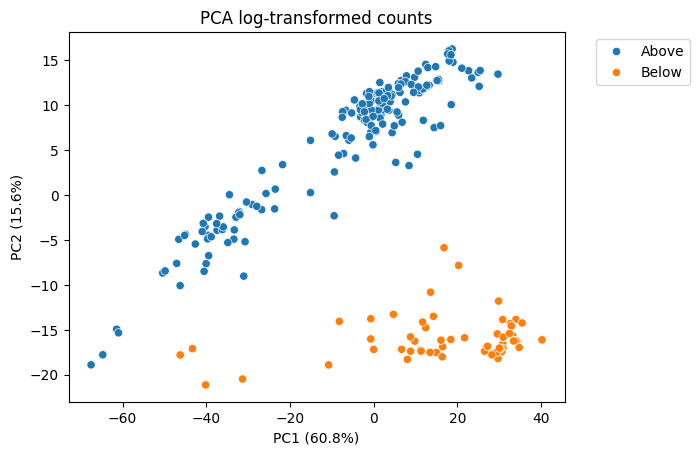

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Log-transform (same idea as your histogram)
log_counts = np.log10(counts + 1)

# Transpose: samples should be rows
X = log_counts.T

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

# Plot
sns.scatterplot(
    x=pca_result[:, 0],
    y=pca_result[:, 1],
    hue=metadata['classes'],  # or any label you want
    palette='tab10'
)

plt.title("PCA log-transformed counts")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

###PCA samples colored by dataset

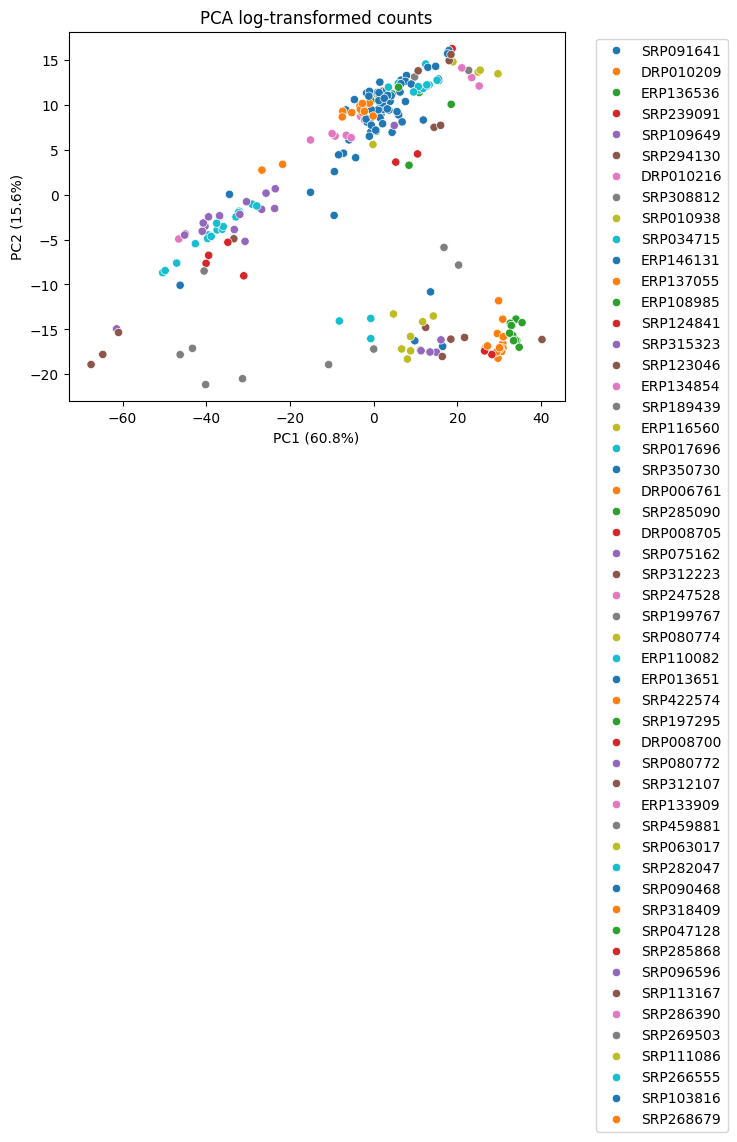

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Log-transform (same idea as your histogram)
log_counts = np.log10(counts + 1)

# Transpose: samples should be rows
X = log_counts.T

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

# Plot
sns.scatterplot(
    x=pca_result[:, 0],
    y=pca_result[:, 1],
    hue=metadata['study_accession'],
    palette='tab10'
)

plt.title("PCA log-transformed counts")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



**What does clustering by study_accession indicate?**  

---
This indicates that batch effects are present in the data.     
Thus, the model may learn technical differences instead of biology.


###3. Sample-level quality control

We measure sparsity using the fraction of zero counts per sample.

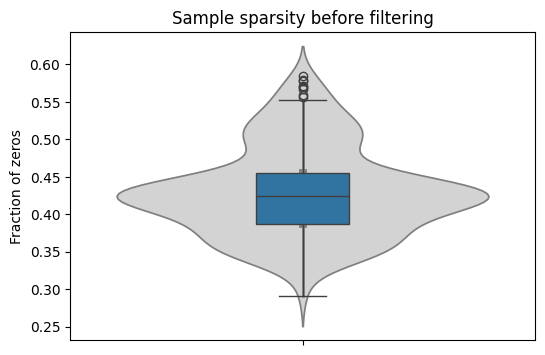

In [ ]:
zero_frac = (counts == 0).mean(axis=0)

plt.figure(figsize=(6,4))
sns.violinplot(y=zero_frac, color='lightgray')
sns.boxplot(y=zero_frac, width=0.2)
plt.title("Sample sparsity before filtering")
plt.ylabel("Fraction of zeros")
plt.show()

**Choose a value to keep samples with a defined percentage of zeros**

Create a table to know the percentiles and the fraction of zeros in every 2.5% of data

In [ ]:
import pandas as pd
import numpy as np

# zero fraction per sample
zero_frac = (counts == 0).sum(axis=0) / counts.shape[0]

# define percentiles every 2.5%
percentiles = np.arange(0, 101, 2.5)

# compute values
percentile_values = np.percentile(zero_frac, percentiles)

# create a table
percentile_table = pd.DataFrame({
    "Percentile": percentiles,
    "Fraction of zeros": percentile_values
})
percentile_table
#percentile_table.tail(10)  # show last 10 rows

,Percentile,Fraction of zeros
0,0.0,0.29040
1,2.5,0.34156
2,5.0,0.34440
3,7.5,0.35040
4,10.0,0.35460
5,12.5,0.35945
6,15.0,0.36314
7,17.5,0.37466
8,20.0,0.37952
9,22.5,0.38311


**Interpretation:**  

- Samples with high zero fraction have low signal

- These may represent poor sequencing quality or technical issues

###Threshold visualization
Visualize the number of samples that will be filtered after removing the 17.5% of samples with more zeros.

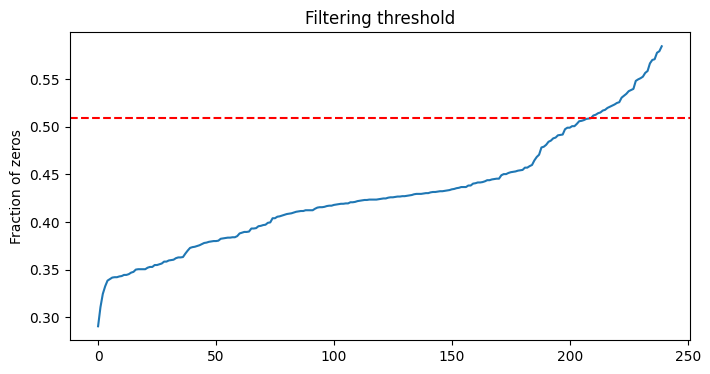

In [ ]:
qc_sorted = zero_frac.sort_values()

plt.figure(figsize=(8,4))
plt.plot(qc_sorted.values)
plt.axhline(0.50955, color='red', linestyle='--')
plt.title("Filtering threshold")
plt.ylabel("Fraction of zeros")
plt.show()

Samples with high zero fraction have low information that can be used to train a model

---
- **What biological or technical factors could explain high sparsity?**

- **Why is a percentile-based cutoff preferable than other approaches?**

###4. Filter low-quality samples

We will use only the 82.5% of all samples, these have less than 48.55% of genes with 0 counts.



/tmp/ipykernel_1556/473672228.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="stage", y="value", data=df, palette=["gray", "skyblue"])


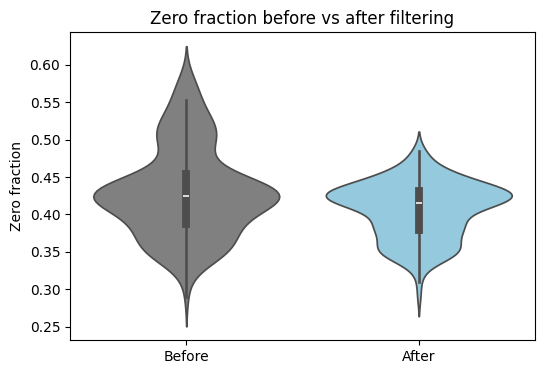

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



keep_samples = zero_frac < 0.48551
counts = counts.loc[:, keep_samples]
metadata = metadata.loc[keep_samples]

zero_frac_after = (counts == 0).mean(axis=0)


# Combine into one DataFrame
df = pd.DataFrame({
    "value": list(zero_frac) + list(zero_frac_after),
    "stage": ["Before"] * len(zero_frac) + ["After"] * len(zero_frac_after)
})

# Single panel plot
plt.figure(figsize=(6,4))
sns.violinplot(x="stage", y="value", data=df, palette=["gray", "skyblue"])

plt.title("Zero fraction before vs after filtering")
plt.xlabel("")
plt.ylabel("Zero fraction")

plt.show()

The distribution becomes tighter and lower

We removed noisy samples, improving data quality.

---

- **How might removing too many samples affect generalization?**

###5. Gene filtering

We remove genes with low expression. Here we will filter out those genes with less than 5 counts in at least 20% of samples.

In [ ]:
# Gene filtering: remove low-expression genes

# Minimum count threshold:
# A gene must have at least this many reads to be considered "expressed"
min_count = 5

# Minimum number of samples:
# A gene must meet the min_count threshold in at least 20% of samples
min_samples = int(0.2 * counts.shape[1])  # counts.shape[1] = number of samples

# Create a boolean mask:
# For each gene (row), count how many samples have counts >= min_count
# Keep genes that meet the threshold in enough samples
keep_genes = (counts >= min_count).sum(axis=1) >= min_samples

# Apply the filter:
# Keep only the genes that passed the criteria
counts = counts.loc[keep_genes]

###5.1 Barplot showing the number of genes after the filter

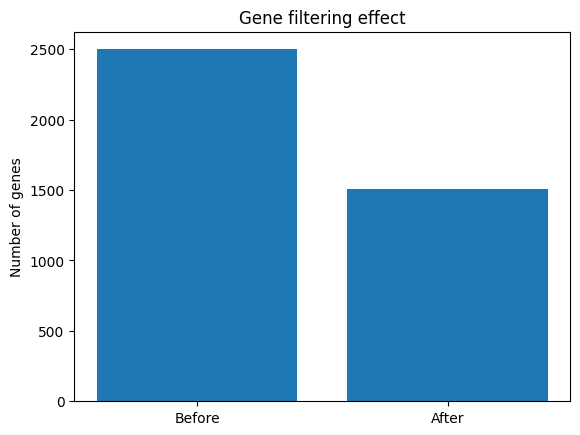

In [ ]:
plt.bar(['Before', 'After'], [len(keep_genes), counts.shape[0]])
plt.title("Gene filtering effect")
plt.ylabel("Number of genes")
plt.show()

Many genes are removed because they carry little information.

This reduces noise and improves model performance.

---

**Why are near-zero genes harmful for ML models?**


##6. Batch Effects Correction
Batch effects are unwanted technical differences between samples caused by things like:

- Different labs  
- Different sequencing runs  
- Different dates or machines  

These differences are not biological, but they can look like real signal.

###6.1 Filter datasets with one sample

First, we check how many samples per dataset were kept after the filters were applied.


---

- **How might batch imbalance bias the model’s predictions?**
- **Could the model learn technical variation instead of biological signal? Why?**
- **How can we manage this situations?**

In [ ]:
batch_counts = metadata['study_accession'].value_counts()
print(batch_counts)

study_accession
SRP091641    55
ERP136536    12
ERP137055    11
DRP010209     8
ERP110082     8
SRP350730     6
DRP008705     6
DRP006761     6
SRP123046     5
ERP108985     5
DRP010216     4
SRP063017     4
ERP146131     4
SRP090468     3
ERP133909     3
SRP312107     3
SRP096596     3
SRP239091     3
SRP315323     3
SRP080774     3
DRP008700     3
SRP017696     3
SRP318409     2
SRP111086     2
SRP294130     2
ERP116560     2
SRP308812     2
SRP034715     2
SRP189439     2
SRP247528     2
SRP124841     1
SRP109649     1
SRP010938     1
SRP197295     1
SRP199767     1
SRP285090     1
SRP459881     1
SRP075162     1
SRP047128     1
SRP113167     1
SRP286390     1
SRP266555     1
SRP103816     1
ERP013651     1
SRP268679     1
Name: count, dtype: int64


###6.2 Filter out those datsets with less than 3 samples

In [ ]:
ybatch_counts = metadata['study_accession'].value_counts()
valid_batches = batch_counts[batch_counts >= 2].index
metadata_filtered = metadata[metadata['study_accession'].isin(valid_batches)]
counts_filtered = counts.loc[:, metadata_filtered.index]

###6.3 Compute logCPM on filtered counts
ComBat is an algorithm designed to remove batch effects from high-throughput data like transcriptomics. ComBat assumes data are approximately normally distributed and homoscedastic, while raw RNA-seq counts are:
highly skewed, mean-variance dependent, closer to negative binomial, not normal

Therefore, we transform counts to logCPM to make them suitable for ComBat.

In [ ]:
library_sizes = counts_filtered.sum(axis=0)
cpm_filtered = counts_filtered.div(library_sizes, axis=1) * 1e6
log_cpm_filtered = np.log2(cpm_filtered + 1)

###6.4 ComBat batch correction

In [ ]:
from pycombat import Combat

combat = Combat()

counts_np = log_cpm_filtered.T.values.astype(float)
batch_np = metadata_filtered['study_accession'].values
covars = pd.get_dummies(metadata_filtered['classes'], drop_first=True)

counts_combat_np = combat.fit_transform(counts_np, batch_np, X=covars.values)
counts_combat = pd.DataFrame(
    counts_combat_np.T,
    index=log_cpm_filtered.index,
    columns=log_cpm_filtered.columns
)





/usr/local/lib/python3.12/dist-packages/pycombat/pycombat.py:79: RuntimeWarning: divide by zero encountered in divide
  (abs(del_sq_post - del_sq_prior) / del_sq_prior).max())


###6.5 PCA after batch correction colored by dataset

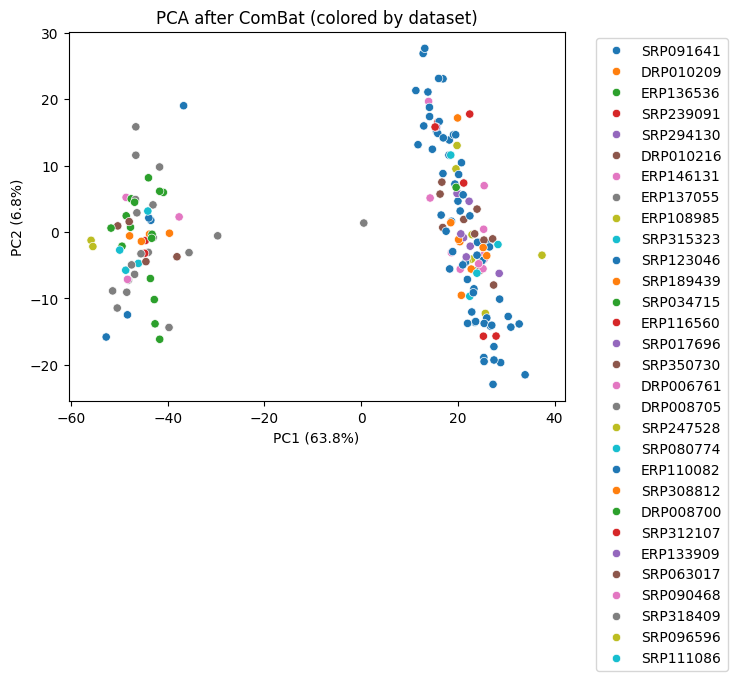

In [ ]:
pca_corrected = PCA(n_components=2)
pca_data_corrected = pca_corrected.fit_transform(counts_combat.T)

sns.scatterplot(
    x=pca_data_corrected[:, 0],
    y=pca_data_corrected[:, 1],
    hue=metadata_filtered['study_accession'],
    palette='tab10',
    legend='full'
)
plt.title("PCA after ComBat (colored by dataset)")
plt.xlabel(f"PC1 ({pca_corrected.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_corrected.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

###6.6 PCA after batch correction colored by class

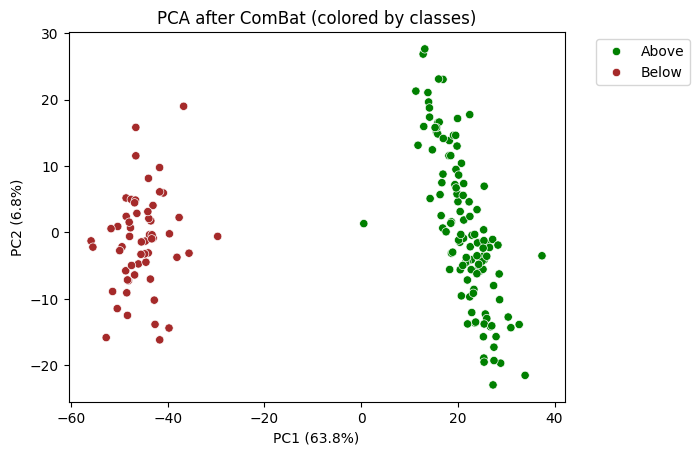

In [ ]:
sns.scatterplot(
    x=pca_data_corrected[:, 0],
    y=pca_data_corrected[:, 1],
    hue=metadata_filtered['classes'],
    palette={'Above':'green', 'Below':'brown'},
    legend='full'
)
plt.title("PCA after ComBat (colored by classes)")
plt.xlabel(f"PC1 ({pca_corrected.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_corrected.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

**How did the structure change after batch correction?**  
**Why correct batch effects before training a machine learning model?**

---
Samples now mix across batches  
Biological variation becomes more visible


##7. Split Data and Feature Scaling

###7.1 Split the data into training and test subsets

The dataset is divided into 70% training and 30% testing subsets. This separation is essential to avoid data leakage, as it ensures that the model is trained only on the training data and evaluated on previously unseen test data, providing a reliable estimate of its generalization performance

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Extract feature matrix (X) and labels (y)
# -> Transpose is used so that rows = samples and columns = genes (features)
X = counts_combat.T.values

# -> Target variable containing class labels for each sample
y = metadata_filtered['classes']

# Train-test split (FIRST)
# -> Split the dataset into training (70%) and testing (30%) subsets
# -> stratify=y ensures that class proportions are preserved in both sets
# -> random_state=42 guarantees reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)


### 7.2 Feature scaling
Gene expression data can vary widely in magnitude across genes. Some genes may have very large values, while others remain relatively low, even after normalization.

Machine learning models such as Support Vector Machines (SVMs) are sensitive to these differences in scale because they rely on distances between samples. If features are not scaled properly, genes with larger values can dominate the model, biasing the results.

Feature scaling standardizes each gene so that all features contribute equally to the model. This step improves model performance, stability, and convergence.

To **avoid data leakage**, the scaling parameters (mean and standard deviation) are computed only on the training dataset. These parameters are then applied to transform both the training and test data. This ensures that no information from the test set influences the training process, preserving the validity of the model evaluation.

In [ ]:
# Feature scaling (Fit only in train dataset)

# Initialize the scaler (standardizes features to mean=0, std=1)
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
# -> The scaler learns the mean and standard deviation from X_train ONLY
X_train_scaled = scaler.fit_transform(X_train)

# Apply the SAME transformation to the test data
# -> Important: we do NOT fit again on X_test to avoid data leakage
X_test_scaled = scaler.transform(X_test)

# Keep the original variable name
X_scaled = X_train_scaled


After feature scaling we check if any NAs were introduced to the data.

**Do NAs exist?  
How many?**

In [ ]:
# Check for NaNs
print("Do NAs exists in scaled data?", np.isnan(X_train_scaled).any())
print("How many NAs in scaled data:", np.isnan(X_train_scaled).sum())



Do NAs exists in scaled data? False
How many NAs in scaled data: 0


---
* Why is feature scaling essential for Support Vector Machines?
* What other methods can be used to scale or normalize features?
* Is feature scaling always necessary? Why or why not?


##8. Model training

We use a Support Vector Machine model to classify biological samples into above- and below-ground tissues using gene expression data as input features. SVMs are well-suited for high-dimensional datasets, such as transcriptomic data, where the number of features (genes) is large.

An SVM works by finding the optimal boundary (hyperplane) that best separates the classes in a high-dimensional space, maximizing the distance (margin) between them.


###8.1 Support Vector Machine classifiers

####Kernel functions

SVMs can use different kernels to model relationships in the data. A kernel defines how the data are transformed to find a separating boundary.

**Linear kernel**

Finds a straight-line (or flat hyperplane) boundary.
Works well when the data are already linearly separable.

**Polynomial kernel**

Creates curved boundaries by considering interactions between features.
Useful when relationships are more complex but still structured.

**RBF (Radial Basis Function) kernel**

Maps data into a higher-dimensional space to create very flexible boundaries.
Can capture complex, non-linear patterns in the data.



###8.2 Train a SVM classifier using a Radial Basis Function
In this SVM model, we use the RBF kernel for non-linear separation and stimates the probability of the prediction.

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True)

# Fit the model on the training data
svm.fit(X_train_scaled, y_train)



SVC(probability=True)

####Model is now trained and ready to predict classes of the Test Dataset

##9. Use the SVM Model to Predict Test Dataset Classes

Once the SVM model is trained on the training data, we can use it to predict the classes of samples in the test set. This allows us to evaluate how well the model generalizes to unseen data.

Input: scaled gene expression features from the test dataset (X_test)
Output: predicted tissue class labels (y_pred)
Optional: predicted probabilities for each class (y_score) for more detailed evaluation

**Key points:**

- Prediction is independent of the training labels — the model only sees the features.  
- We can use the predictions to compute metrics like accuracy and build a confusion matrix.  
- Probabilities allow further analysis, _e.g._, identifying samples where the model is less confident.

###9.1 Predict and get the probabilities of each class

In [ ]:

# Define the classes from the trained SVM
classes = svm.classes_
print("Classes:", classes)

# Get predicted probabilities for each class
# This returns an array of shape (n_samples, n_classes)
y_score = svm.predict_proba(X_test_scaled)
print("y_score shape:", y_score.shape)

# Show unique labels in the test set
print("y_test unique:", y_test.unique())

Classes: ['Above' 'Below']
y_score shape: (54, 2)
y_test unique: ['Above' 'Below']


After predicting the classes with the SVM model, we can also inspect the probabilities assigned to each class. This helps us understand how confident the model is about its predictions for each sample.

Each row corresponds to a sample in the test set.
Each column corresponds to a class (Above, Below).
Values are probabilities between 0 and 1. The higher the value, the more confident the model is that the sample belongs to that class.



---

**View the class prediction probabilities of the first samples**   
Classes probability:  
[Above, Below]


In [ ]:
y_score[0:5]



array([[0.99385176, 0.00614824],
       [0.97702642, 0.02297358],
       [0.99162609, 0.00837391],
       [0.98932017, 0.01067983],
       [0.99068368, 0.00931632]])

###9.2 Predict the Classes in the Test Dataset
After training the SVM model, we use it to predict the class labels of the test set samples.

The predicted classes are the final output of the model for each sample.
These predictions can be compared with the true labels to evaluate model performance.  

Later, we will use these predictions to build a confusion matrix, which shows correct and incorrect classifications.

In [ ]:

y_pred = svm.predict(X_test_scaled)
y_pred[0:5]


array(['Above', 'Above', 'Above', 'Above', 'Above'], dtype=object)

###9.3 Create a Confusion Matrix to check the number of missclassifications


A confusion matrix summarizes how well the model predicts each class:

- Diagonal = **correct predictions**  
- Off-diagonal = **misclassifications**

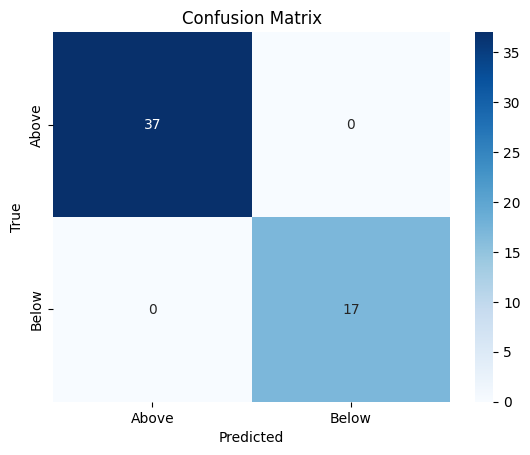

In [ ]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm.classes_,
            yticklabels=svm.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

##10. Train a similar model using the original data

Here, we will train a siimilar SVM model without any preprocessing or batch correction. This allows us to compare the performance of the raw data model versus the preprocessed data model.


###10.1 Load the original data

In [ ]:
counts_raw = pd.read_csv(file1_path, index_col=0)
metadata_raw = pd.read_csv(file2_path, index_col=0)


###10.2 Log-transform expression data and scalation of genes

In [ ]:
log_counts_raw = np.log2(counts_raw + 1)

X_raw = log_counts_raw.T.values
y_raw = metadata_raw['classes']

scaler_raw = StandardScaler()
X_raw_scaled = scaler_raw.fit_transform(X_raw)

###10.3 Train the model using original data

In [ ]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw_scaled, y_raw,
    test_size=0.3,
    stratify=y_raw,
    random_state=42
)

svm_raw = SVC(kernel='rbf', probability=True)
svm_raw.fit(Xr_train, yr_train)

SVC(probability=True)

###10.4 Evaluate the model trained using original data



Classes (RAW): ['Above' 'Below']


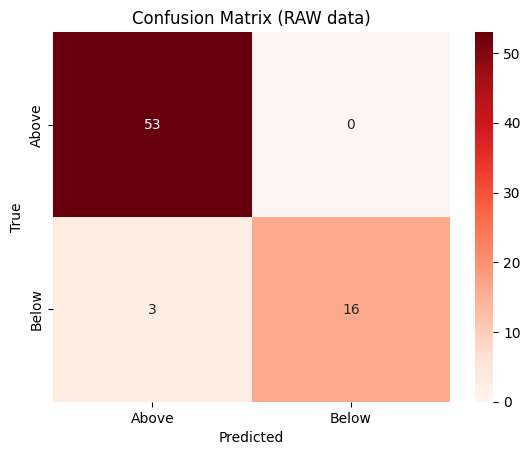

In [ ]:
# Define the classes for the raw SVM model
classes_raw = svm_raw.classes_
print("Classes (RAW):", classes_raw)

# Predict using raw model
yr_pred = svm_raw.predict(Xr_test)

# Then compute confusion matrix
cm_raw = confusion_matrix(yr_test, yr_pred, labels=classes_raw)

# Then compute the confusion matrix
cm_raw = confusion_matrix(yr_test, yr_pred, labels=classes_raw)

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Reds',
            xticklabels=classes_raw,
            yticklabels=classes_raw)

plt.title("Confusion Matrix (RAW data)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

##11. Compare accuracy of the two models

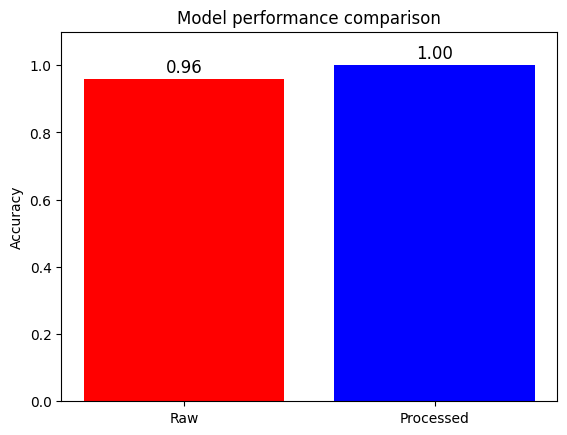

In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

acc_raw = accuracy_score(yr_test, yr_pred)
acc_processed = accuracy_score(y_test, y_pred)

bars = plt.bar(['Raw', 'Processed'], [acc_raw, acc_processed],
               color=['red', 'blue'])

# Add text annotations on top of the bars
for bar, acc in zip(bars, [acc_raw, acc_processed]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,  # slightly above the bar
             f"{acc:.2f}", ha='center', va='bottom', fontsize=12)

plt.ylim(0, 1.1)  # leave some space for the labels
plt.ylabel("Accuracy")
plt.title("Model performance comparison")
plt.show()


---
How much did accuracy improve after preprocessing?

Which classes benefited the most?

Does the raw model confuse biologically different tissues? Why?

Which preprocessing step likely contributed most to improvement?

Would removing batch correction change the results significantly?

**Conclusions:**

The raw model often:
- Has lower metrics, such as accuracy, AUC values, etc.
- Shows more confusion between classes
- Is biased by technical noise

The processed model:

- Separates classes better
- Has cleaner decision boundaries
- Generalizes better

##Final message

Models learn hidden patterns, machine learning performance depends more on data quality than on model complexity.
